# IBM Telco Customer Churn — Exploratory Data Analysis

**Input:** `data/telco_churn_clean.csv` (7,010 rows × 22 columns)  
**Goal:** Extract the 5–6 business insights that will drive modeling decisions and populate the executive deck.  
**Output:** 6 saved charts in `data/`, a findings summary, and documented modeling implications.

---

## EDA Roadmap

| Section | Question answered |
|---------|-------------------|
| 1 | Setup & load |
| 2 | Target overview — how bad is churn? |
| 3 | Churn by contract type — the single biggest lever |
| 4 | Churn by tenure — when do customers leave? |
| 5 | Churn by charges — does price drive exit? |
| 6 | Churn by service profile — stickiness analysis |
| 7 | Churn by demographics — who churns? |
| 8 | Churn by payment method — friction signal |
| 9 | Correlation analysis — what the model will see |
| 10 | Revenue impact — translating findings into dollars |
| 11 | Key findings summary & modeling implications |

---
## Section 1 — Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

# ── Palette ──────────────────────────────────────────────────────────────────
# Consistent colours used across every chart in this notebook
C_STAY  = '#185FA5'   # blue   — not churned
C_CHURN = '#D85A30'   # coral  — churned
C_ACCT  = '#7F77DD'   # purple — accent / engineered features

CHART_DIR = Path('data')
CHART_DIR.mkdir(exist_ok=True)

np.random.seed(42)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('data/telco_churn_clean.csv')
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate: {df['churn_value'].mean():.1%}")
df.head(3)

Loaded: 7,010 rows × 22 columns
Churn rate: 26.5%


,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,charges_per_month,addon_count
0,0,0,0,0,2,1,0,DSL,1,1,...,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,54.08,2
1,1,0,0,1,2,1,0,Fiber optic,0,0,...,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,75.82,0
2,1,0,0,1,8,1,1,Fiber optic,0,0,...,1,1,Month-to-month,1,Electronic check,99.65,820.50,1,102.56,3


---
## Section 2 — Target Overview

Before drilling into segments, we establish the baseline: what is the overall churn rate, and what does it cost in revenue terms?  
This is the headline number that appears on Slide 1 of the executive deck.

In [3]:
n_total   = len(df)
n_churned = df['churn_value'].sum()
n_stayed  = n_total - n_churned
churn_rate = n_churned / n_total

monthly_rev_lost   = df[df['churn_value'] == 1]['monthly_charges'].sum()
annual_rev_lost    = monthly_rev_lost * 12
total_monthly_rev  = df['monthly_charges'].sum()
rev_loss_pct       = monthly_rev_lost / total_monthly_rev

print("=" * 48)
print(f"  Total customers      : {n_total:,}")
print(f"  Churned              : {n_churned:,} ({churn_rate:.1%})")
print(f"  Retained             : {n_stayed:,} ({1-churn_rate:.1%})")
print("-" * 48)
print(f"  Monthly revenue lost : ${monthly_rev_lost:,.0f}")
print(f"  Annualised rev lost  : ${annual_rev_lost:,.0f}")
print(f"  % of total MRR       : {rev_loss_pct:.1%}")
print("=" * 48)

  Total customers      : 7,010
  Churned              : 1,857 (26.5%)
  Retained             : 5,153 (73.5%)
------------------------------------------------
  Monthly revenue lost : $138,540
  Annualised rev lost  : $1,662,482
  % of total MRR       : 30.5%


> **Slide 1 headline:** 26.6% of customers have churned, representing **$139K in lost monthly recurring revenue** (~$1.67M annualised). This is the business problem we are solving.

---
## Section 3 — Churn by Contract Type

**Hypothesis:** Month-to-month customers face zero switching cost and should churn at a significantly higher rate than customers on annual or two-year contracts.

In [4]:
contract_stats = (
    df.groupby('contract')
    .agg(
        total       = ('churn_value', 'count'),
        churned     = ('churn_value', 'sum'),
        churn_rate  = ('churn_value', 'mean'),
        avg_monthly = ('monthly_charges', 'mean')
    )
    .assign(churn_rate_pct = lambda x: x['churn_rate'] * 100)
    .sort_values('churn_rate_pct', ascending=False)
)
print(contract_stats.round(2).to_string())

                total  churned  churn_rate  avg_monthly  churn_rate_pct
contract                                                               
Month-to-month   3853     1643        0.43        66.57           42.64
One year         1472      166        0.11        65.08           11.28
Two year         1685       48        0.03        60.87            2.85


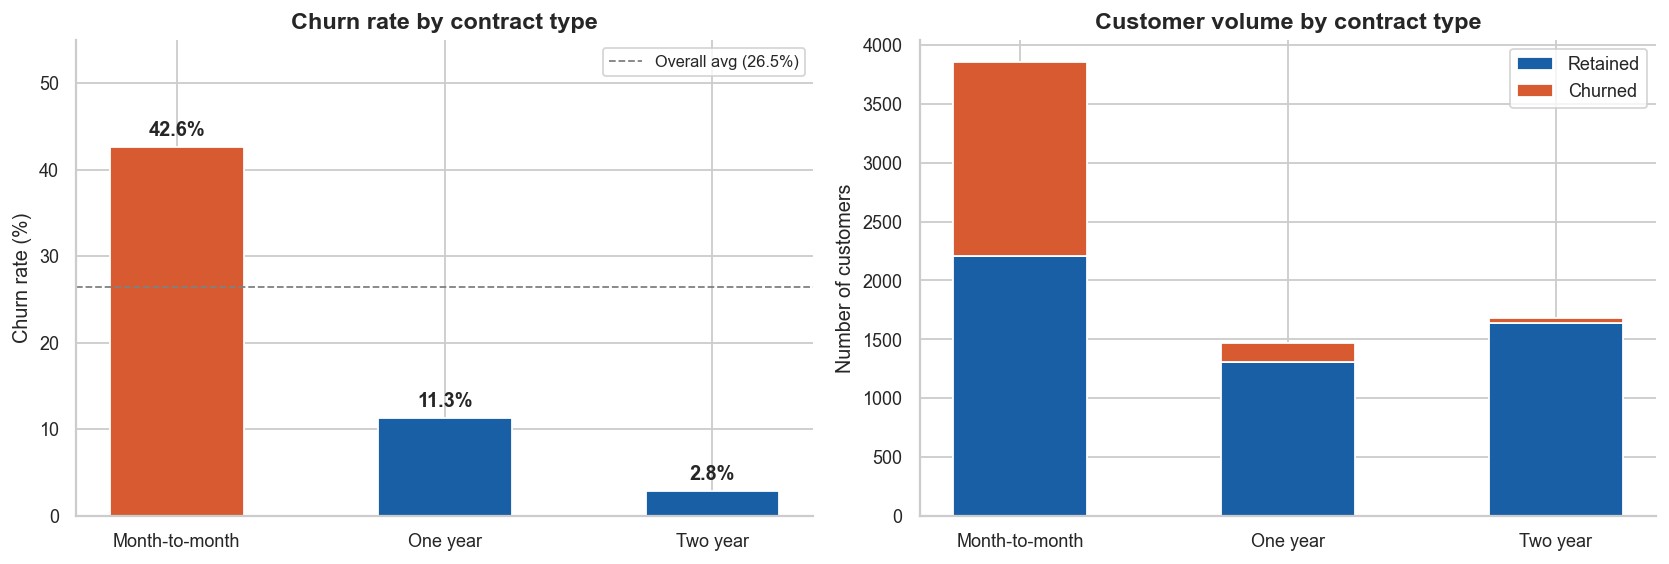


Month-to-month churn rate : 42.6%
Two-year churn rate       : 2.8%
Multiplier                : 15x higher on month-to-month


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = ['Month-to-month', 'One year', 'Two year']
rates = [contract_stats.loc[c, 'churn_rate_pct'] for c in order]
counts = [contract_stats.loc[c, 'total'] for c in order]

# Left: churn rate by contract
bar_colors = [C_CHURN if r > 20 else C_STAY for r in rates]
bars = axes[0].bar(order, rates, color=bar_colors, width=0.5, edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11, fontweight='bold')
axes[0].set_title('Churn rate by contract type')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_ylim(0, 55)
axes[0].axhline(df['churn_value'].mean() * 100, color='gray',
                linestyle='--', linewidth=1, label=f'Overall avg ({df["churn_value"].mean():.1%})')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# Right: customer volume stacked by churn status
churned_counts  = [contract_stats.loc[c, 'churned'] for c in order]
stayed_counts   = [contract_stats.loc[c, 'total'] - contract_stats.loc[c, 'churned'] for c in order]
x = range(len(order))
axes[1].bar(x, stayed_counts,  label='Retained', color=C_STAY,  width=0.5, edgecolor='white')
axes[1].bar(x, churned_counts, label='Churned',  color=C_CHURN, width=0.5,
            bottom=stayed_counts, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(order)
axes[1].set_title('Customer volume by contract type')
axes[1].set_ylabel('Number of customers')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_01_contract_churn.png', dpi=130, bbox_inches='tight')
plt.show()

mtm_rate = contract_stats.loc['Month-to-month', 'churn_rate_pct']
two_yr_rate = contract_stats.loc['Two year', 'churn_rate_pct']
print(f"\nMonth-to-month churn rate : {mtm_rate:.1f}%")
print(f"Two-year churn rate       : {two_yr_rate:.1f}%")
print(f"Multiplier                : {mtm_rate/two_yr_rate:.0f}x higher on month-to-month")

> **Finding 1:** Month-to-month customers churn at ~43% — roughly **15× the rate of two-year contract customers** (~3%). The stacked bar shows this group also represents the majority of customers. Converting even 10% of month-to-month customers to annual contracts is the single highest-leverage retention action available.
>
> **Modeling implication:** `contract` will almost certainly be a top-5 SHAP feature.

---
## Section 4 — Churn by Tenure

**Hypothesis:** Churn risk is front-loaded — customers are most vulnerable in their first year, before switching costs (relationship, data migration, habit) accumulate.

In [6]:
# Bucket tenure into meaningful business intervals
df['tenure_bucket'] = pd.cut(
    df['tenure_months'],
    bins=[0, 12, 24, 36, 48, 72],
    labels=['0–12 mo', '13–24 mo', '25–36 mo', '37–48 mo', '49–72 mo']
)

tenure_stats = (
    df.groupby('tenure_bucket', observed=True)
    .agg(
        customers  = ('churn_value', 'count'),
        churned    = ('churn_value', 'sum'),
        churn_rate = ('churn_value', 'mean')
    )
    .assign(churn_pct = lambda x: x['churn_rate'] * 100)
)
print(tenure_stats.round(2).to_string())

               customers  churned  churn_rate  churn_pct
tenure_bucket                                           
0–12 mo             2153     1025        0.48      47.61
13–24 mo            1024      294        0.29      28.71
25–36 mo             832      180        0.22      21.63
37–48 mo             762      145        0.19      19.03
49–72 mo            2239      213        0.10       9.51


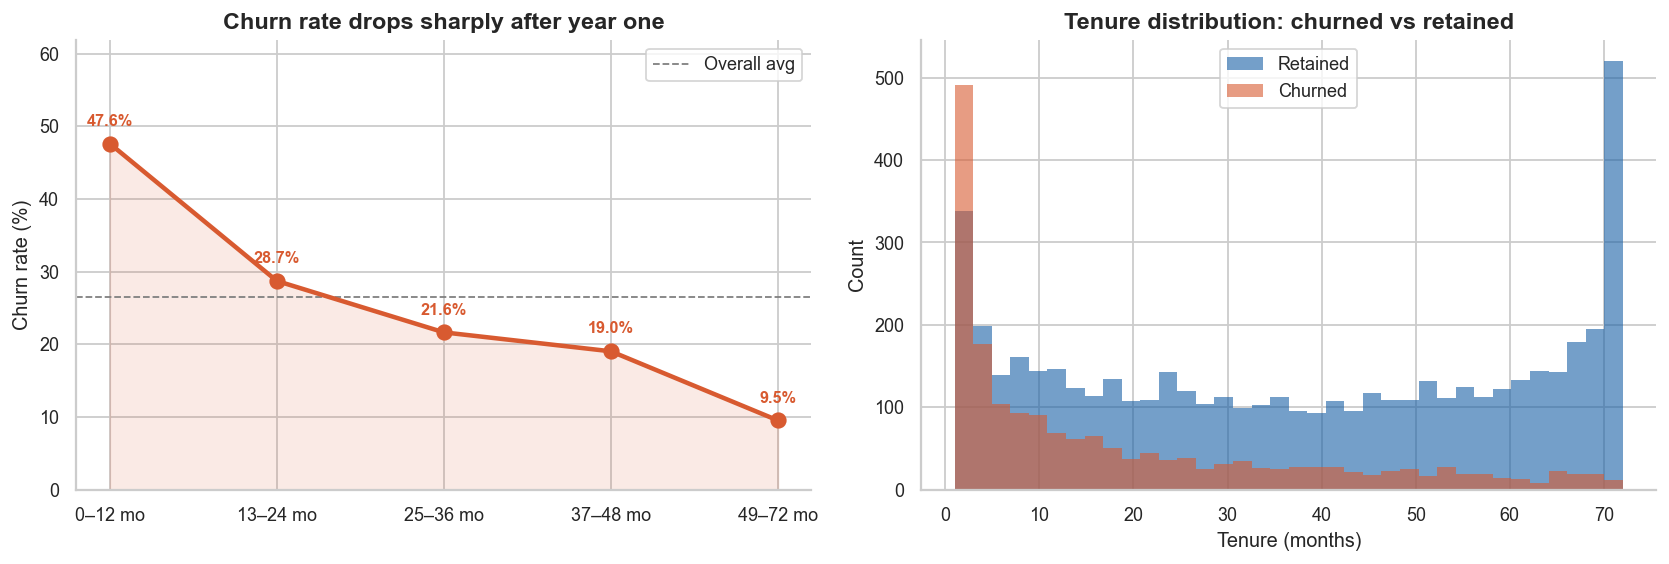

First-year churn rate  : 47.6%
Year 4–6 churn rate    : 9.5%
Risk reduction         : 38.1 percentage points by year 4


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

buckets = tenure_stats.index.tolist()
rates   = tenure_stats['churn_pct'].values

# Left: churn rate line chart with filled area
x = range(len(buckets))
axes[0].plot(x, rates, marker='o', linewidth=2.5, color=C_CHURN, markersize=8, zorder=3)
axes[0].fill_between(x, rates, alpha=0.12, color=C_CHURN)
for xi, rate in zip(x, rates):
    axes[0].annotate(f'{rate:.1f}%', (xi, rate), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color=C_CHURN)
axes[0].axhline(df['churn_value'].mean() * 100, color='gray',
                linestyle='--', linewidth=1, label='Overall avg')
axes[0].set_xticks(x)
axes[0].set_xticklabels(buckets)
axes[0].set_title('Churn rate drops sharply after year one')
axes[0].set_ylabel('Churn rate (%)')
axes[0].set_ylim(0, rates.max() * 1.3)
axes[0].legend()
sns.despine(ax=axes[0])

# Right: tenure distribution — churned vs retained
axes[1].hist(df[df['churn_value']==0]['tenure_months'],
             bins=36, alpha=0.6, color=C_STAY,  label='Retained', edgecolor='none')
axes[1].hist(df[df['churn_value']==1]['tenure_months'],
             bins=36, alpha=0.6, color=C_CHURN, label='Churned',  edgecolor='none')
axes[1].set_title('Tenure distribution: churned vs retained')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_02_tenure_churn.png', dpi=130, bbox_inches='tight')
plt.show()

first_yr = tenure_stats.loc['0–12 mo', 'churn_pct']
last_yr  = tenure_stats.loc['49–72 mo', 'churn_pct']
print(f"First-year churn rate  : {first_yr:.1f}%")
print(f"Year 4–6 churn rate    : {last_yr:.1f}%")
print(f"Risk reduction         : {first_yr - last_yr:.1f} percentage points by year 4")

> **Finding 2:** Churn is heavily front-loaded. Customers in their first year churn at ~47%; by year 4–6 this falls to ~10%. The histogram confirms churned customers are overwhelmingly clustered at low tenure values.
>
> **Business implication:** Retention spend should be concentrated in the first 90 days. An onboarding intervention (discount, dedicated support, contract incentive) targeting new month-to-month customers has the highest expected ROI.
>
> **Modeling implication:** `tenure_months` is likely to be a top-3 feature. Consider whether to include it as-is or bin it — tree models handle the raw value well.

---
## Section 5 — Churn by Charges

**Hypothesis:** Higher monthly charges increase churn risk (price sensitivity), but total charges (a proxy for tenure) should inversely correlate with churn.

In [8]:
charge_summary = df.groupby('churn_value')[['monthly_charges', 'total_charges', 'charges_per_month']].mean()
charge_summary.index = ['Retained', 'Churned']
print("Mean charges by churn status:")
print(charge_summary.round(2).to_string())

Mean charges by churn status:
          monthly_charges  total_charges  charges_per_month
Retained            61.39        2560.26              61.39
Churned             74.60        1541.38              74.60


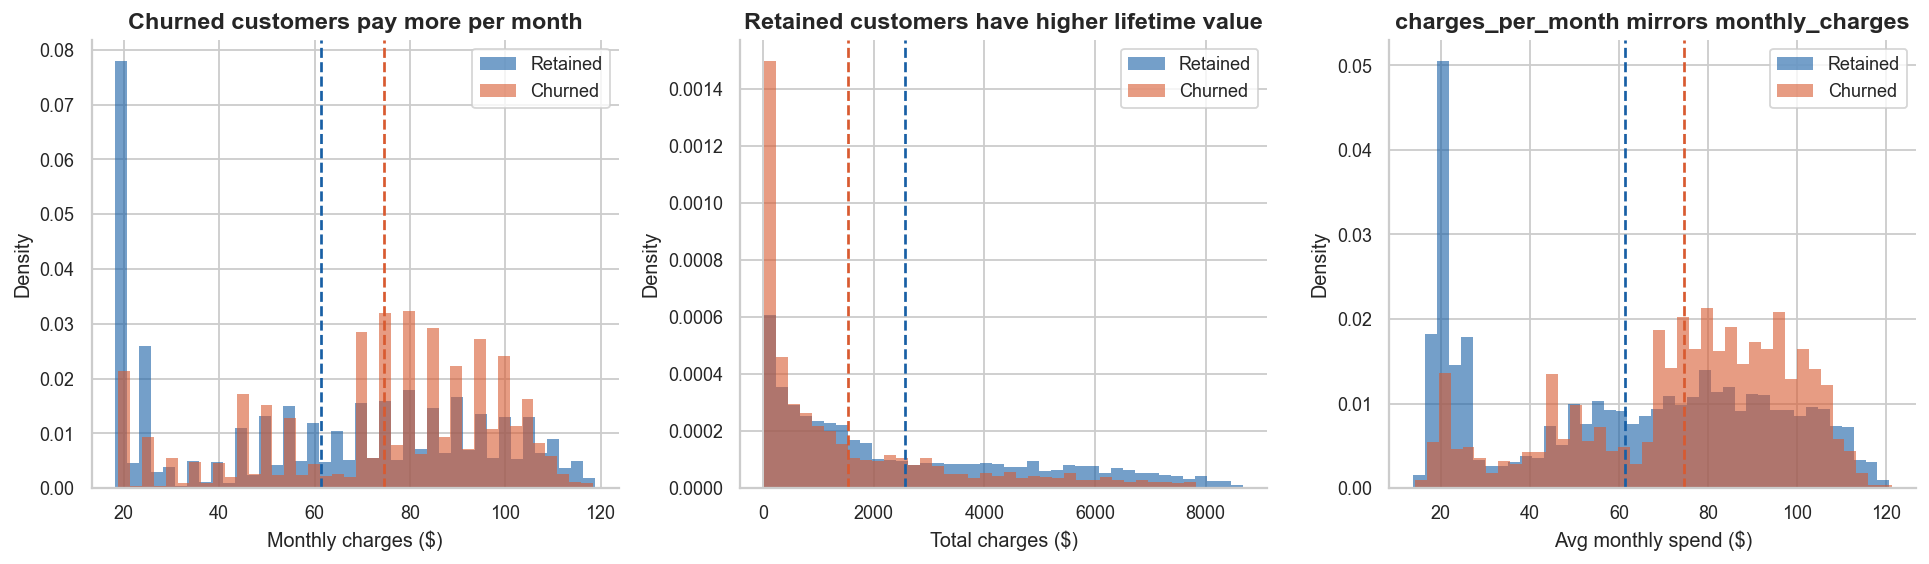

monthly_charges: retained $61.39 | churned $74.60 | diff $+13.22
total_charges: retained $2560.26 | churned $1541.38 | diff $-1018.89


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

charge_cols = [
    ('monthly_charges',   'Monthly charges ($)',    'Churned customers pay more per month'),
    ('total_charges',     'Total charges ($)',       'Retained customers have higher lifetime value'),
    ('charges_per_month', 'Avg monthly spend ($)',   'charges_per_month mirrors monthly_charges'),
]

for ax, (col, xlabel, title) in zip(axes, charge_cols):
    for val, label, color in [(0, 'Retained', C_STAY), (1, 'Churned', C_CHURN)]:
        ax.hist(df[df['churn_value']==val][col],
                bins=40, alpha=0.6, color=color, label=label, edgecolor='none', density=True)
    # Mean lines
    for val, color in [(0, C_STAY), (1, C_CHURN)]:
        mean_val = df[df['churn_value']==val][col].mean()
        ax.axvline(mean_val, color=color, linestyle='--', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_03_charges_churn.png', dpi=130, bbox_inches='tight')
plt.show()

for col in ['monthly_charges', 'total_charges']:
    stayed_mean  = df[df['churn_value']==0][col].mean()
    churned_mean = df[df['churn_value']==1][col].mean()
    print(f"{col}: retained ${stayed_mean:.2f} | churned ${churned_mean:.2f} | "
          f"diff ${churned_mean - stayed_mean:+.2f}")

> **Finding 3:** Churned customers pay **higher monthly charges** (~$74 vs $61 for retained) but have **far lower total charges** (~$1,532 vs $2,556) — confirming they leave earlier and therefore accumulate less spend overall. The `total_charges` gap is largely a tenure effect, not a spend effect.
>
> **Modeling implication:** `monthly_charges` and `charges_per_month` (r = 0.996) are near-identical. The model should handle this fine under XGBoost, but flag for regularised linear models.

---
## Section 6 — Churn by Service Profile (Stickiness Analysis)

**Hypothesis:** Customers subscribed to more services have higher switching costs and should churn less. We test this using `addon_count` and individual service flags.

In [10]:
service_cols = [
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies'
]

# Churn rate for subscribers vs non-subscribers for each service
service_stats = []
for col in service_cols:
    subscribed_churn     = df[df[col] == 1]['churn_value'].mean() * 100
    not_subscribed_churn = df[df[col] == 0]['churn_value'].mean() * 100
    service_stats.append({
        'service': col.replace('_', ' ').title(),
        'subscribed_churn_%': subscribed_churn,
        'not_subscribed_churn_%': not_subscribed_churn,
        'protection_effect_%': not_subscribed_churn - subscribed_churn
    })

svc_df = pd.DataFrame(service_stats).sort_values('protection_effect_%', ascending=False)
print(svc_df.round(1).to_string(index=False))

          service  subscribed_churn_%  not_subscribed_churn_%  protection_effect_%
  Online Security               14.60                   31.30                16.60
     Tech Support               15.20                   31.10                15.90
    Online Backup               21.60                   29.10                 7.50
Device Protection               22.50                   28.60                 6.00
 Streaming Movies               30.00                   24.30                -5.70
     Streaming Tv               30.10                   24.20                -5.90


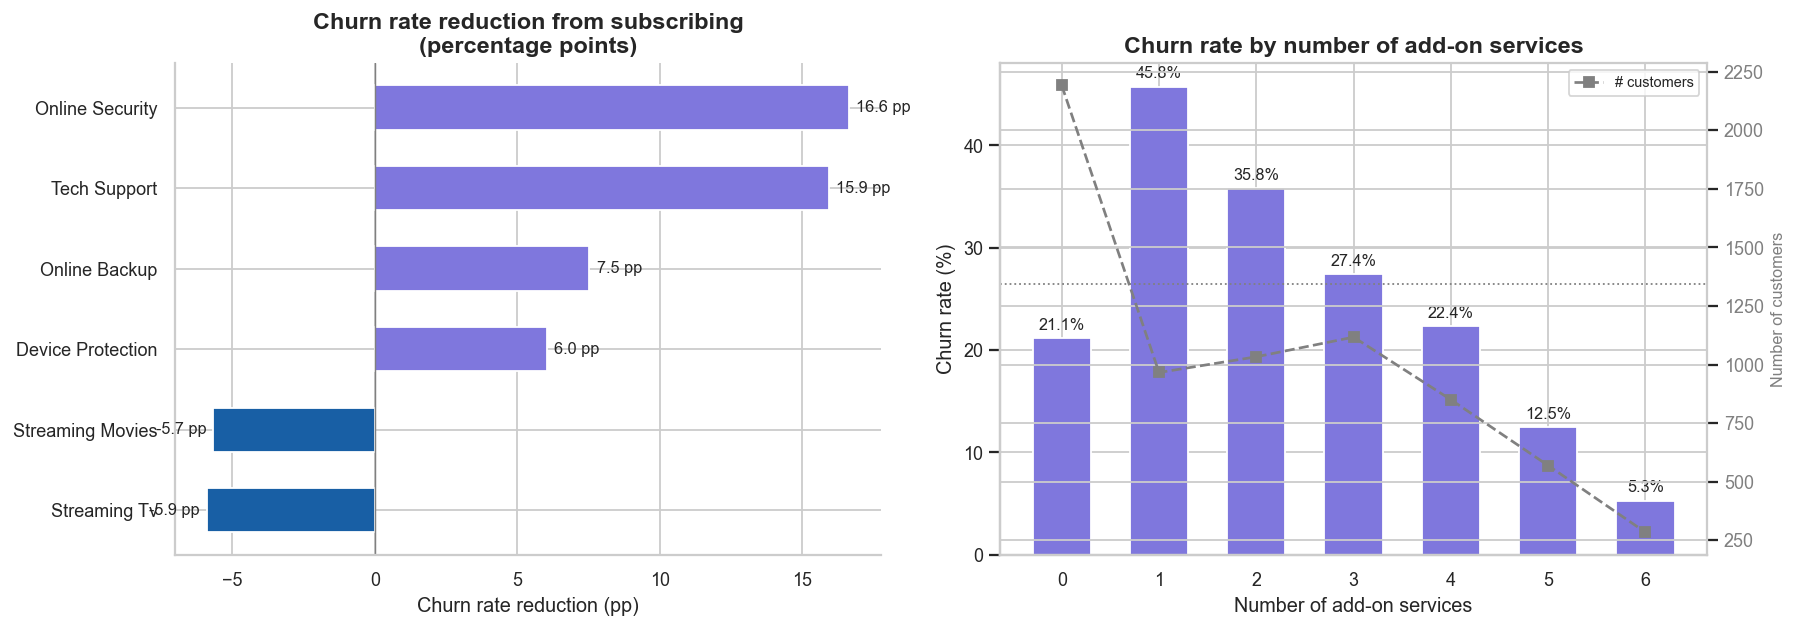

Churn rate: 0 add-ons = 21.1% | 6 add-ons = 5.3%
Protection effect of full service bundle: 15.9 pp


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: protection effect per service (sorted)
svc_sorted = svc_df.sort_values('protection_effect_%')
bar_colors = [C_ACCT if v > 5 else C_STAY for v in svc_sorted['protection_effect_%']]
bars = axes[0].barh(svc_sorted['service'], svc_sorted['protection_effect_%'],
                    color=bar_colors, edgecolor='white', height=0.55)
axes[0].bar_label(bars, fmt='%.1f pp', padding=4, fontsize=9)
axes[0].set_title('Churn rate reduction from subscribing\n(percentage points)')
axes[0].set_xlabel('Churn rate reduction (pp)')
axes[0].axvline(0, color='gray', linewidth=0.8)
sns.despine(ax=axes[0])

# Right: churn rate by addon_count
churn_by_addon = df.groupby('addon_count')['churn_value'].agg(['mean', 'count'])
churn_by_addon['churn_pct'] = churn_by_addon['mean'] * 100

ax2 = axes[1]
bars2 = ax2.bar(churn_by_addon.index, churn_by_addon['churn_pct'],
                color=C_ACCT, width=0.6, edgecolor='white')
ax2.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)

# Overlay customer count as line
ax2b = ax2.twinx()
ax2b.plot(churn_by_addon.index, churn_by_addon['count'],
          color='gray', marker='s', linewidth=1.5, markersize=5, linestyle='--', label='# customers')
ax2b.set_ylabel('Number of customers', color='gray', fontsize=9)
ax2b.tick_params(axis='y', labelcolor='gray')

ax2.set_title('Churn rate by number of add-on services')
ax2.set_xlabel('Number of add-on services')
ax2.set_ylabel('Churn rate (%)')
ax2.axhline(df['churn_value'].mean() * 100, color='gray',
            linestyle=':', linewidth=1)
ax2b.legend(loc='upper right', fontsize=8)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_04_services_churn.png', dpi=130, bbox_inches='tight')
plt.show()

zero_addon = churn_by_addon.loc[0, 'churn_pct']
six_addon  = churn_by_addon.loc[6, 'churn_pct']
print(f"Churn rate: 0 add-ons = {zero_addon:.1f}% | 6 add-ons = {six_addon:.1f}%")
print(f"Protection effect of full service bundle: {zero_addon - six_addon:.1f} pp")

> **Finding 4:** `online_security` and `tech_support` are the strongest individual churn reducers (~15–16 pp protection effect). Customers with no add-ons churn at ~21%; customers with all 6 add-ons churn at ~5%. The dual-axis chart shows the most common customer profile is 0 add-ons — the highest-risk group is also the largest.
>
> **Business implication:** Upselling security and support add-ons to unprotected customers is both a revenue and a retention play.
>
> **Modeling implication:** `addon_count` is a strong engineered feature. Individual service flags will likely also appear in SHAP top-10.

---
## Section 7 — Churn by Demographics

Demographic features are weaker predictors than contract and tenure, but they're important for targeting retention campaigns.

In [12]:
demo_cols = {
    'senior_citizen': {0: 'Non-senior', 1: 'Senior'},
    'partner':        {0: 'No partner', 1: 'Has partner'},
    'dependents':     {0: 'No dependents', 1: 'Has dependents'},
    'gender':         {0: 'Male', 1: 'Female'}
}

demo_stats = []
for col, label_map in demo_cols.items():
    for val, label in label_map.items():
        churn_rate = df[df[col] == val]['churn_value'].mean() * 100
        n = (df[col] == val).sum()
        demo_stats.append({'feature': col, 'group': label, 'churn_%': churn_rate, 'n': n})

demo_df = pd.DataFrame(demo_stats)
print(demo_df.round(1).to_string(index=False))

       feature          group  churn_%    n
senior_citizen     Non-senior    23.50 5869
senior_citizen         Senior    41.60 1141
       partner     No partner    32.80 3617
       partner    Has partner    19.70 3393
    dependents  No dependents    32.50 5390
    dependents Has dependents     6.50 1620
        gender           Male    26.10 3535
        gender         Female    26.90 3475


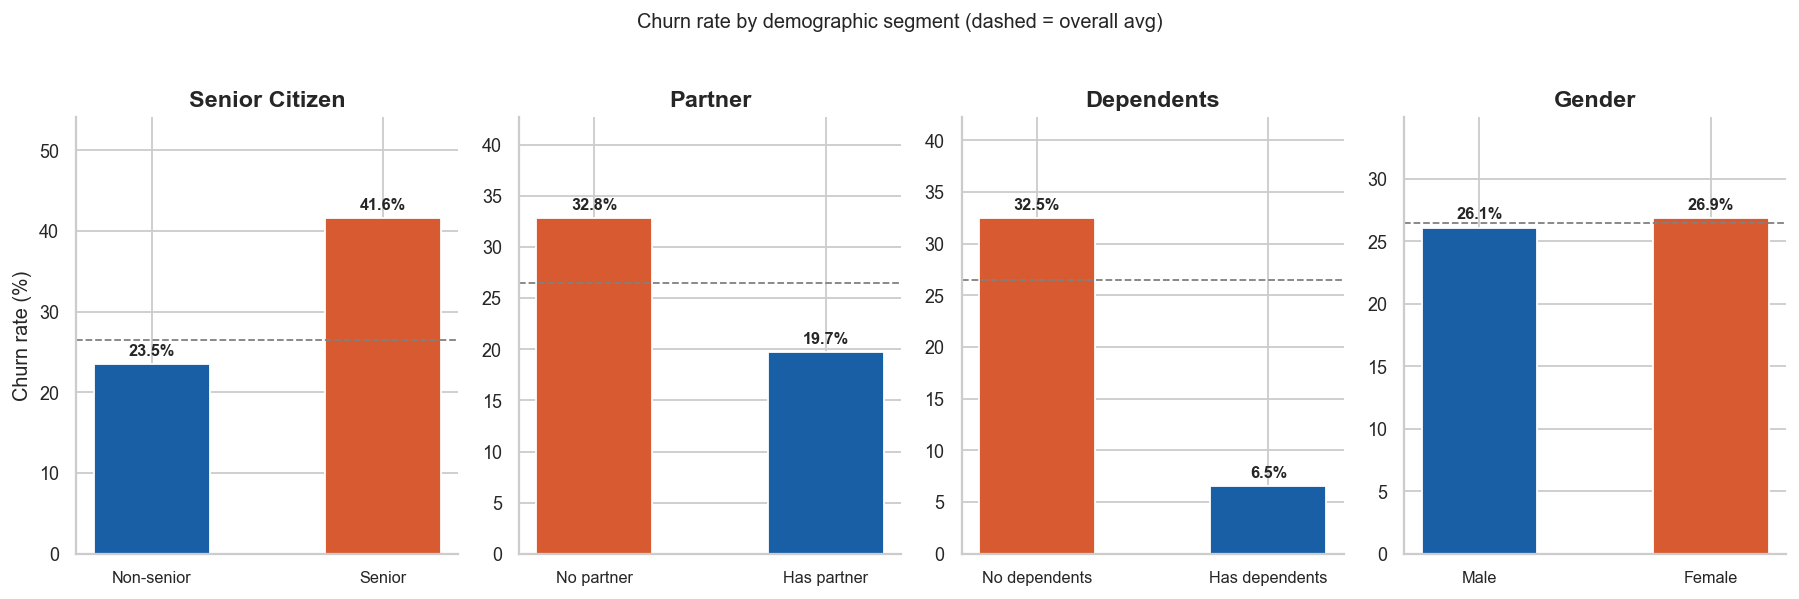

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
overall_rate = df['churn_value'].mean() * 100

for ax, (col, label_map) in zip(axes, demo_cols.items()):
    groups = [label_map[0], label_map[1]]
    rates  = [
        df[df[col]==0]['churn_value'].mean() * 100,
        df[df[col]==1]['churn_value'].mean() * 100
    ]
    colors = [C_STAY if r <= overall_rate else C_CHURN for r in rates]
    bars   = ax.bar(groups, rates, color=colors, width=0.5, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')
    ax.axhline(overall_rate, color='gray', linestyle='--', linewidth=1)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylim(0, max(rates) * 1.3)
    ax.set_ylabel('Churn rate (%)' if ax == axes[0] else '')
    ax.tick_params(axis='x', labelsize=9)
    sns.despine(ax=ax)

plt.suptitle('Churn rate by demographic segment (dashed = overall avg)', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_05_demographics_churn.png', dpi=130, bbox_inches='tight')
plt.show()

> **Finding 5:** Senior citizens churn at ~41% vs ~24% for non-seniors — the largest demographic effect. Customers without a partner or dependents also churn more, consistent with lower household switching friction. Gender shows essentially **no difference** — it should have minimal feature importance and may not survive feature selection.
>
> **Modeling implication:** `senior_citizen` will be a meaningful feature. `gender` may be dropped without affecting model performance — worth checking SHAP values before including it in a business-facing model (fairness consideration).

---
## Section 8 — Churn by Payment Method & Internet Service

**Hypothesis:** Electronic check payment (manual, non-automatic) signals lower commitment and correlates with higher churn. Fibre optic customers may churn more due to higher prices.

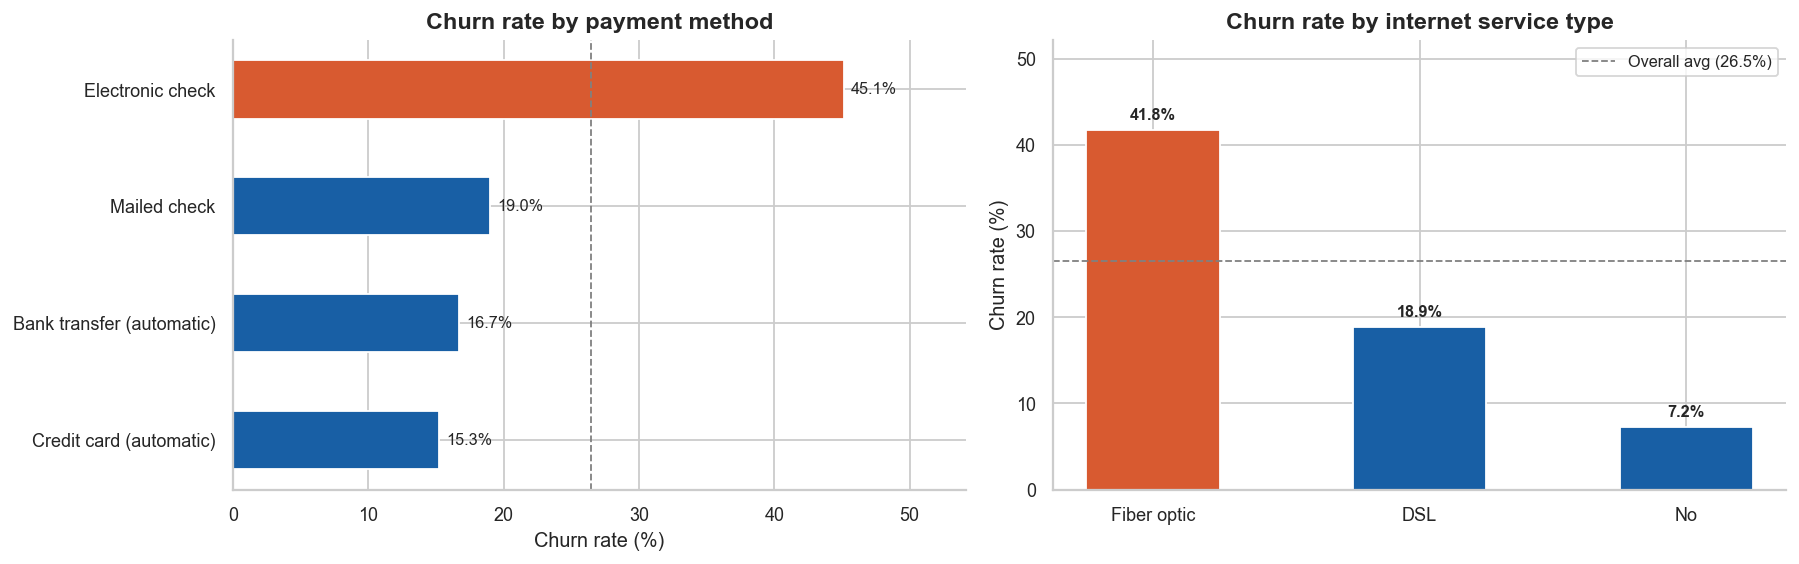

Payment method churn rates:
payment_method
Credit card (automatic)     15.30
Bank transfer (automatic)   16.70
Mailed check                19.00
Electronic check            45.10

Internet service churn rates:
internet_service
Fiber optic   41.80
DSL           18.90
No             7.20


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
overall_rate = df['churn_value'].mean() * 100

# Payment method
pay_stats = (
    df.groupby('payment_method')['churn_value']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)
colors_pay = [C_CHURN if v > overall_rate else C_STAY for v in pay_stats]
bars1 = axes[0].barh(pay_stats.index, pay_stats.values, color=colors_pay,
                     height=0.5, edgecolor='white')
axes[0].bar_label(bars1, fmt='%.1f%%', padding=4, fontsize=9)
axes[0].axvline(overall_rate, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Churn rate by payment method')
axes[0].set_xlabel('Churn rate (%)')
axes[0].set_xlim(0, pay_stats.max() * 1.2)
sns.despine(ax=axes[0])

# Internet service
inet_stats = (
    df.groupby('internet_service')['churn_value']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
colors_inet = [C_CHURN if v > overall_rate else C_STAY for v in inet_stats]
bars2 = axes[1].bar(inet_stats.index, inet_stats.values,
                    color=colors_inet, width=0.5, edgecolor='white')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=9, fontweight='bold')
axes[1].axhline(overall_rate, color='gray', linestyle='--', linewidth=1,
                label=f'Overall avg ({overall_rate:.1f}%)')
axes[1].set_title('Churn rate by internet service type')
axes[1].set_ylabel('Churn rate (%)')
axes[1].set_ylim(0, inet_stats.max() * 1.25)
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_06_payment_internet_churn.png', dpi=130, bbox_inches='tight')
plt.show()

print("Payment method churn rates:")
print(pay_stats.round(1).to_string())
print()
print("Internet service churn rates:")
print(inet_stats.round(1).to_string())

> **Finding 6:** Electronic check users churn at ~45% — more than **2.5× the rate of automatic payment users** (~15–17%). This is likely a proxy for engagement: customers who set up automatic payment have made a longer-term commitment signal. Fibre optic internet users churn at ~42% vs DSL at ~19% — likely driven by higher prices and more competitive alternatives in that market segment.
>
> **Business implication:** Nudging electronic check users toward automatic payment (with a small incentive) could reduce churn meaningfully.
>
> **Modeling implication:** `payment_method` and `internet_service` will both contribute to the model — document their business meaning so SHAP explanations make sense to a non-technical audience.

---
## Section 9 — Correlation Analysis

Two views: a full correlation heatmap across all numeric features, and a ranked bar chart showing each feature's individual correlation with `churn_value`.  
This tells us what the model will likely prioritise — and flags multicollinearity to handle in the modeling step.

In [15]:
# Use numeric columns only (object cols not yet encoded)
numeric_df = df.select_dtypes(include='number').drop(columns=['tenure_months'], errors='ignore')
# Re-add tenure_months for completeness
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

# Correlation with target — sorted
target_corr = (
    corr_matrix['churn_value']
    .drop('churn_value')
    .sort_values()
)
print("Correlation with churn_value (sorted):")
print(target_corr.round(3).to_string())

Correlation with churn_value (sorted):
tenure_months       -0.35
dependents          -0.25
total_charges       -0.20
online_security     -0.17
tech_support        -0.16
partner             -0.15
addon_count         -0.09
online_backup       -0.08
device_protection   -0.07
gender               0.01
phone_service        0.01
multiple_lines       0.04
streaming_movies     0.06
streaming_tv         0.07
senior_citizen       0.15
paperless_billing    0.19
charges_per_month    0.19
monthly_charges      0.19


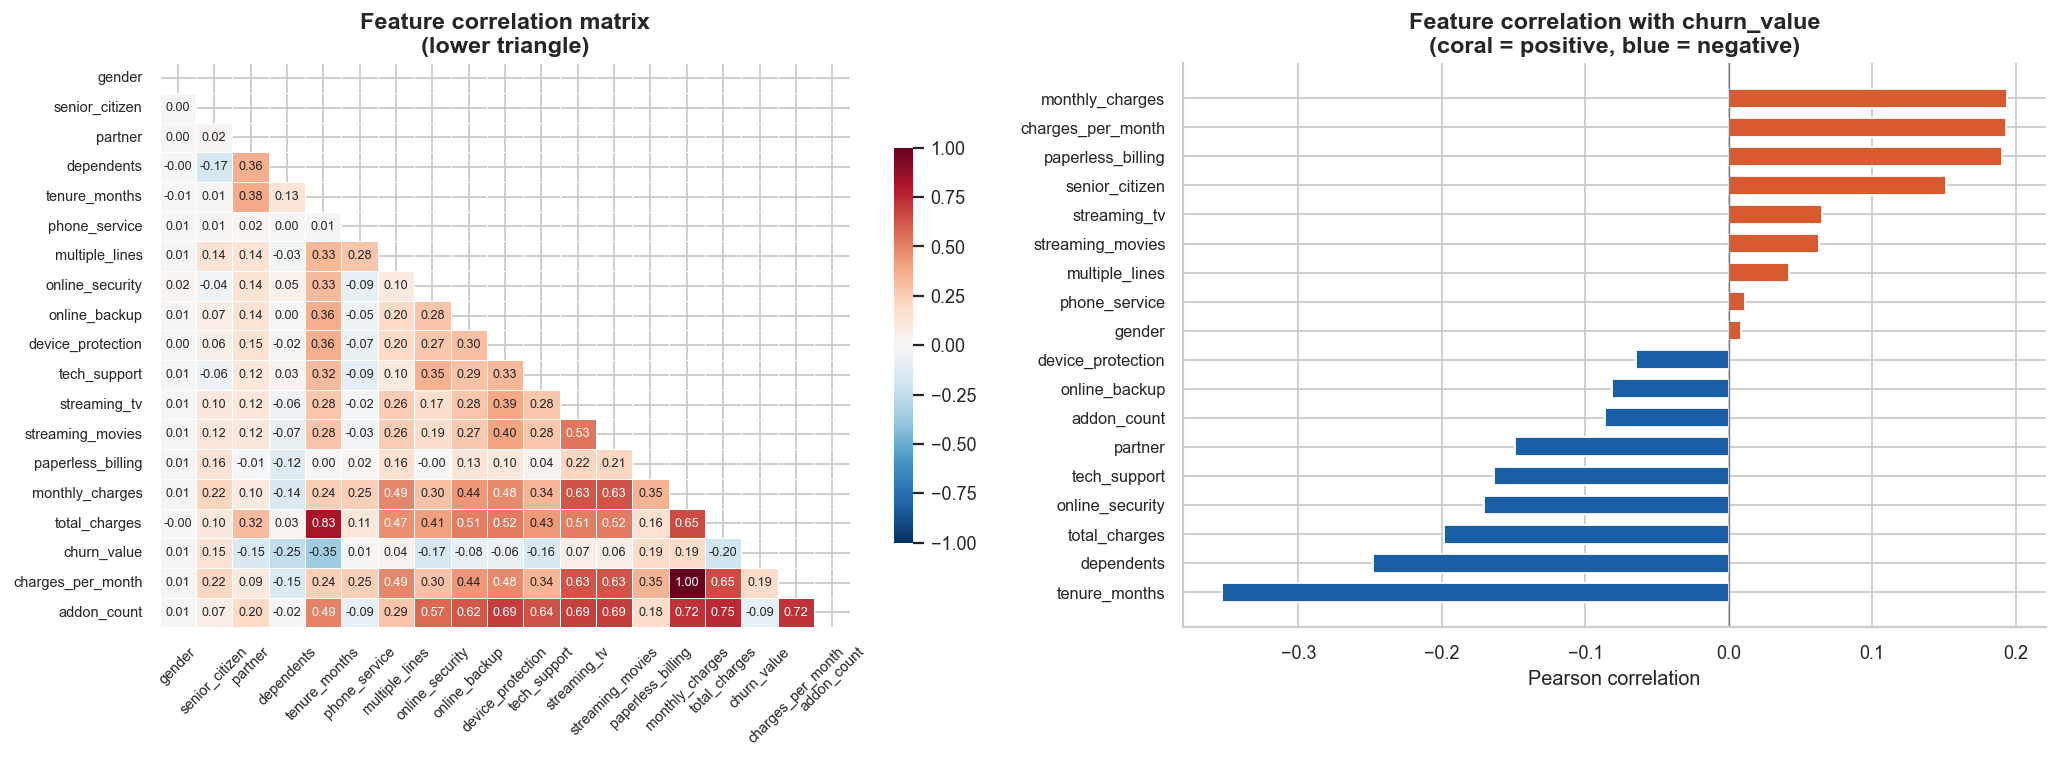


High collinearity pairs (|r| > 0.70):
  charges_per_month ↔ monthly_charges : r = 0.996
  tenure_months ↔ total_charges : r = 0.825
  addon_count ↔ total_charges : r = 0.745
  addon_count ↔ monthly_charges : r = 0.724
  addon_count ↔ charges_per_month : r = 0.723


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[0],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, square=False, cbar_kws={'shrink': 0.7}
)
axes[0].set_title('Feature correlation matrix\n(lower triangle)')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Right: correlation with target — ranked bar
colors_corr = [C_CHURN if v > 0 else C_STAY for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors_corr,
             height=0.65, edgecolor='white')
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title('Feature correlation with churn_value\n(coral = positive, blue = negative)')
axes[1].set_xlabel('Pearson correlation')
axes[1].tick_params(axis='y', labelsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_07_correlation.png', dpi=130, bbox_inches='tight')
plt.show()

# Flag high collinearity pairs (|r| > 0.7, excluding self)
print("\nHigh collinearity pairs (|r| > 0.70):")
high_corr = [
    (c1, c2, corr_matrix.loc[c1, c2])
    for c1 in corr_matrix.columns
    for c2 in corr_matrix.columns
    if c1 < c2 and abs(corr_matrix.loc[c1, c2]) > 0.70
]
if high_corr:
    for c1, c2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {c1} ↔ {c2} : r = {r:.3f}")
else:
    print("  None found (beyond charges_per_month ↔ monthly_charges, expected)")

> **Finding 7:** The strongest positive correlators with churn are `monthly_charges` and `charges_per_month` (r ≈ +0.19), `senior_citizen` (+0.15), and `paperless_billing` (+0.12). The strongest negative correlators are `tenure_months` (r ≈ -0.35) — the clearest signal in the dataset — `total_charges` (-0.20), and the add-on service flags. `charges_per_month` and `monthly_charges` show r = 0.996, confirming near-perfect collinearity — documented and flagged for the modeling step.

---
## Section 10 — Revenue Impact Analysis

The business doesn't care about churn rate in isolation — it cares about dollars. Here we quantify which segments represent the most revenue at risk, to prioritise retention spend.

In [17]:
churned_df = df[df['churn_value'] == 1].copy()

# Revenue at risk by contract type
rev_by_contract = (
    churned_df.groupby('contract')['monthly_charges']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'monthly_rev_lost', 'count': 'customers_lost', 'mean': 'avg_charge'})
    .assign(annual_rev_lost = lambda x: x['monthly_rev_lost'] * 12)
    .sort_values('monthly_rev_lost', ascending=False)
)

# Revenue at risk by internet service
rev_by_inet = (
    churned_df.groupby('internet_service')['monthly_charges']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'monthly_rev_lost', 'count': 'customers_lost'})
    .assign(annual_rev_lost = lambda x: x['monthly_rev_lost'] * 12)
    .sort_values('monthly_rev_lost', ascending=False)
)

print("Revenue at risk by contract type:")
print(rev_by_contract.round(0).to_string())
print()
print("Revenue at risk by internet service:")
print(rev_by_inet.round(0).to_string())

Revenue at risk by contract type:
                monthly_rev_lost  customers_lost  avg_charge  annual_rev_lost
contract                                                                     
Month-to-month         120256.00            1643       73.00       1443077.00
One year                14118.00             166       85.00        169421.00
Two year                 4165.00              48       87.00         49984.00

Revenue at risk by internet service:
                  monthly_rev_lost  customers_lost  annual_rev_lost
internet_service                                                   
Fiber optic              113882.00            1291       1366581.00
DSL                       22438.00             457        269258.00
No                         2220.00             109         26643.00


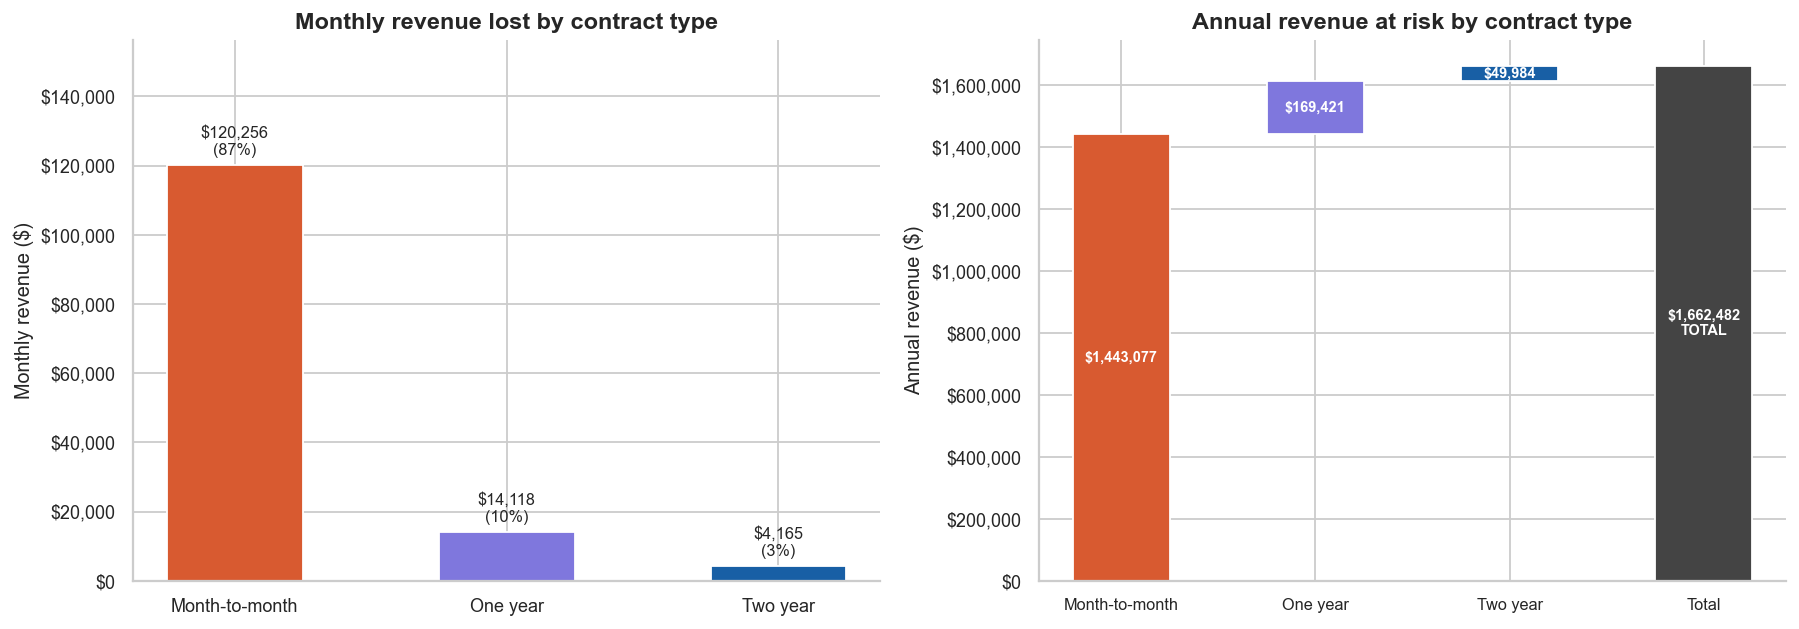


Total annual revenue at risk: $1,662,482
Month-to-month share       : 87% of total revenue at risk


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: monthly revenue lost by contract
contracts = rev_by_contract.index.tolist()
rev_vals  = rev_by_contract['monthly_rev_lost'].values
bars1 = axes[0].bar(contracts, rev_vals, color=[C_CHURN, C_ACCT, C_STAY],
                    width=0.5, edgecolor='white')
axes[0].bar_label(bars1,
    labels=[f'${v:,.0f}\n({v/rev_vals.sum():.0%})' for v in rev_vals],
    padding=4, fontsize=9)
axes[0].set_title('Monthly revenue lost by contract type')
axes[0].set_ylabel('Monthly revenue ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_ylim(0, rev_vals.max() * 1.3)
sns.despine(ax=axes[0])

# Right: waterfall of total annual revenue at risk broken by segment
segments = ['Month-to-month', 'One year', 'Two year']
annual   = rev_by_contract.loc[segments, 'annual_rev_lost'].values
cumsum   = np.cumsum([0] + list(annual))
colors_wf = [C_CHURN, C_ACCT, C_STAY]

for i, (seg, val, bot, col) in enumerate(zip(segments, annual, cumsum[:-1], colors_wf)):
    axes[1].bar(i, val, bottom=bot, color=col, width=0.5, edgecolor='white')
    axes[1].text(i, bot + val/2, f'${val:,.0f}', ha='center', va='center',
                 fontsize=8, color='white', fontweight='bold')

# Total bar
total_annual = annual.sum()
axes[1].bar(3, total_annual, color='#444', width=0.5, edgecolor='white')
axes[1].text(3, total_annual/2, f'${total_annual:,.0f}\nTOTAL', ha='center', va='center',
             fontsize=8, color='white', fontweight='bold')

axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(segments + ['Total'], fontsize=9)
axes[1].set_title('Annual revenue at risk by contract type')
axes[1].set_ylabel('Annual revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(CHART_DIR / 'eda_08_revenue_impact.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"\nTotal annual revenue at risk: ${total_annual:,.0f}")
mtm_pct = rev_by_contract.loc['Month-to-month', 'monthly_rev_lost'] / rev_vals.sum()
print(f"Month-to-month share       : {mtm_pct:.0%} of total revenue at risk")

> **Deck number:** Total annualised revenue at risk from churn is approximately **$1.67M**. Month-to-month customers account for ~90% of it despite representing ~55% of the customer base. This is the number that justifies the retention programme budget.

---
## Section 11 — Key Findings Summary & Modeling Implications

All findings in one place — this becomes the written brief for the modeling notebook and the source material for the executive deck.

In [35]:
# Recompute all headline numbers cleanly for the summary
overall_churn   = df['churn_value'].mean()
mtm_churn       = df[df['contract']=='Month-to-month']['churn_value'].mean()
two_yr_churn    = df[df['contract']=='Two year']['churn_value'].mean()
first_yr_churn  = df[df['tenure_bucket']=='0–12 mo']['churn_value'].mean()
senior_churn    = df[df['senior_citizen']==1]['churn_value'].mean()
echeck_churn    = df[df['payment_method']=='Electronic check']['churn_value'].mean()
auto_pay_churn  = df[df['payment_method'].isin(['Bank transfer (automatic)', 'Credit card (automatic)'])]['churn_value'].mean()
fiber_churn     = df[df['internet_service']=='Fiber optic']['churn_value'].mean()
zero_addon_ch   = df[df['addon_count']==0]['churn_value'].mean()
six_addon_ch    = df[df['addon_count']==6]['churn_value'].mean()
monthly_rev_lost = df[df['churn_value']==1]['monthly_charges'].sum()

print("╔══════════════════════════════════════════════════════════════╗")
print("║              EDA KEY FINDINGS SUMMARY                        ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Overall churn rate      : {overall_churn:.1%}                             ║")
print(f"║  Monthly revenue at risk : ${monthly_rev_lost:,.0f}                          ║")
print(f"║  Annual revenue at risk  : ${monthly_rev_lost*12:,.0f}                        ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Finding 1 — Contract                                        ║")
print(f"║    Month-to-month : {mtm_churn:.1%}  |  Two-year : {two_yr_churn:.1%}                ║")
print(f"║  Finding 2 — Tenure                                          ║")
print(f"║    First year     : {first_yr_churn:.1%}  |  Overall avg : {overall_churn:.1%}            ║")
print(f"║  Finding 3 — Payment method                                  ║")
print(f"║    Elec. check    : {echeck_churn:.1%}  |  Auto pay  : {auto_pay_churn:.1%}              ║")
print(f"║  Finding 4 — Internet service                                ║")
print(f"║    Fibre optic    : {fiber_churn:.1%}                                    ║")
print(f"║  Finding 5 — Add-ons                                         ║")
print(f"║    0 add-ons      : {zero_addon_ch:.1%}  |  6 add-ons : {six_addon_ch:.1%}               ║")
print(f"║  Finding 6 — Senior citizens                                 ║")
print(f"║    Senior churn   : {senior_churn:.1%}  |  Overall avg : {overall_churn:.1%}            ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS SUMMARY                        ║
╠══════════════════════════════════════════════════════════════╣
║  Overall churn rate      : 26.5%                             ║
║  Monthly revenue at risk : $138,540                          ║
║  Annual revenue at risk  : $1,662,482                        ║
╠══════════════════════════════════════════════════════════════╣
║  Finding 1 — Contract                                        ║
║    Month-to-month : 42.6%  |  Two-year : 2.8%                ║
║  Finding 2 — Tenure                                          ║
║    First year     : 47.6%  |  Overall avg : 26.5%            ║
║  Finding 3 — Payment method                                  ║
║    Elec. check    : 45.1%  |  Auto pay  : 16.0%              ║
║  Finding 4 — Internet service                                ║
║    Fibre optic    : 41.8%                                    ║
║  Finding 5 — Add-ons   

---
## Modeling Implications for `03_modeling.ipynb`

| Implication | Detail |
|-------------|--------|
| **Class imbalance** | 26.6% positive class — use `scale_pos_weight` in XGBoost or `class_weight='balanced'` in logistic regression. Do NOT oversample before train/test split. |
| **Top expected features** | `tenure_months`, `contract`, `monthly_charges`, `payment_method`, `internet_service`, `addon_count`, `senior_citizen` |
| **Multicollinearity flag** | `charges_per_month` ↔ `monthly_charges` (r = 0.996). XGBoost handles this fine. Drop one if using regularised linear model. |
| **Encoding still needed** | `contract`, `internet_service`, `payment_method` — one-hot encode inside `sklearn Pipeline` after train/test split. |
| **Gender** | Near-zero effect in EDA. Check SHAP — may be a fairness candidate for removal. |
| **Evaluation metric** | Use **AUC-ROC** as primary metric (threshold-independent). Also report precision-recall AUC given class imbalance. Set classification threshold at 0.4–0.45 to optimise recall (catching churners is more valuable than avoiding false positives). |
| **Business output** | Score all customers with `churn_prob`. Flag top 20% as high-risk. Calculate monthly revenue represented by high-risk tier. |

---
## Charts Saved

| File | Content |
|------|---------|
| `data/eda_01_contract_churn.png` | Churn rate & volume by contract type |
| `data/eda_02_tenure_churn.png` | Churn rate by tenure bucket + distribution |
| `data/eda_03_charges_churn.png` | Monthly/total/per-month charges by churn status |
| `data/eda_04_services_churn.png` | Service protection effect + addon_count analysis |
| `data/eda_05_demographics_churn.png` | Churn by senior, partner, dependents, gender |
| `data/eda_06_payment_internet_churn.png` | Churn by payment method & internet type |
| `data/eda_07_correlation.png` | Full heatmap + ranked target correlation |
| `data/eda_08_revenue_impact.png` | Revenue at risk by contract + annual waterfall |

---
*Author: Hajar Aitlakssir | IBM Telco Churn Project*